# Figure 5c – Applying theoretical profiles to repair maps with Debye effect

Reads `data/processed/figure_5c_profiles.csv` and saves `figures/figure_5c.png`.


In [5]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style, pretty_plot_radial_profile

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=1.5)


In [6]:
df   = pd.read_csv(PROCESSED / 'figure_5c_profiles.csv')
freq = df['freq'].values
profiles = [
    df['rp_b300'].values,
    df['rp_repaired_helix'].values,
    df['rp_repaired_sheet'].values,
    df['rp_repaired_average'].values,
]
labels = [
    r'B-factor: $300\ \AA^{2}$',
    r'Average all-$\alpha$ profiles',
    r'Average all-$\beta$ profiles',
    r'Mixed $\alpha$$\beta$ profiles',
]


Saved figures/figure_5c.png


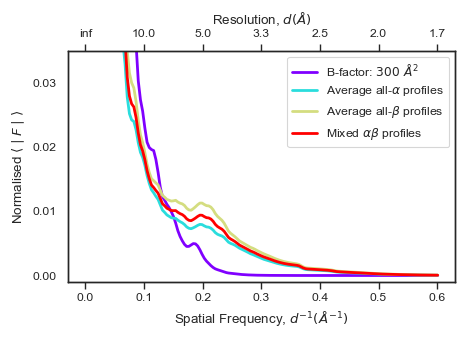

In [12]:
fig = pretty_plot_radial_profile(
    freq, profiles,
    legends=labels,
    logScale=False,
    normalise=True,
    squared_amplitudes=True,
    ylims=[-0.001, 0.035],
    yticks=[0, 0.01, 0.02, 0.03],
    linewidth=2,
    figsize=(5, 3),
    fontsize=11,
)
fig.savefig(FIGURES / 'figure_5c.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_5c.png')
